In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm
from scipy.stats import percentileofscore
import scipy

import seaborn as sns
import cartopy.crs as ccrs

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024
A new version is available: IDL 8.8.3
https://harrisgeospatial.flexnetoperations.com
 


In [33]:
'''
Monthly (raw) data arrays
'''

# land/sea mask
ECHAM5_land_mask = xr.open_dataset('/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/fx/atmos/sftlf/ens00/sftlf_fx_ECHAM5-4_All-Hist_est1_v1-0_ens00_000000-000000.nc')
ECHAM5_land_mask = ECHAM5_land_mask.sel(lon = slice(165,180),lat=slice(-33,-48))

# all-forcing ensemble mean
ECHAM5_ds_all = xr.open_dataset('/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/pr/ensmean/pr_Amon_ECHAM5-4_All-Hist_est1_v1-0_mean_197901-202102.nc')
ECHAM5_ds_all = ECHAM5_ds_all.sel(lon = slice(165,180),lat=slice(-33,-48))
ECHAM5_pr_all = ECHAM5_ds_all.pr.where(ECHAM5_land_mask.sftlf > 0)
# nat-forcing ensemble mean
ECHAM5_ds_nat = xr.open_dataset('/home/stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/pr/ensmean/pr_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_mean_197901-202006.nc')
ECHAM5_ds_nat = ECHAM5_ds_nat.sel(lon = slice(165,180),lat=slice(-33,-48))
ECHAM5_pr_nat = ECHAM5_ds_nat.pr.where(ECHAM5_land_mask.sftlf > 0)
# store means for fingerprinting
ens_means = {'all':ECHAM5_pr_all, 'nat':ECHAM5_pr_nat}

# ERA5 precip, coarsened to ECHAM5 resolution
ERA5_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/1969_2019.nc')
ERA5_ds = ERA5_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
ERA5_ds = ERA5_ds.interp(longitude=ECHAM5_pr_all.lon, latitude=ECHAM5_pr_all.lat, method="linear")
ERA5_tp = ERA5_ds.tp.where(ECHAM5_land_mask.sftlf > 0)


In [41]:
'''
Annual data arrays
'''

ECHAM5_pr_all_annual = ECHAM5_pr_all.resample(time='A').mean()
ECHAM5_pr_all_annual = ECHAM5_pr_all_annual.sel(time=slice('1979','2019'))
# convert kg/m2/s to m/year
ECHAM5_pr_all_annual = ECHAM5_pr_all_annual * 86.400 * 365

ECHAM5_pr_nat_annual = ECHAM5_pr_nat.resample(time='A').mean()
ECHAM5_pr_nat_annual = ECHAM5_pr_nat_annual.sel(time=slice('1979','2019'))
# convert kg/m2/s to m/year
ECHAM5_pr_nat_annual = ECHAM5_pr_nat_annual * 86.400 * 365

ens_means_annual = {'all':ECHAM5_pr_all_annual, 'nat':ECHAM5_pr_nat_annual}

ERA5_tp_annual = ERA5_tp.resample(time='A').mean()
ERA5_tp_annual = ERA5_tp_annual.sel(time=slice('1979','2019'))
# convert m/day to m/year
ERA5_tp_annual = ERA5_tp_annual * 365

In [57]:
'''
Seasonal data arrays
'''

ECHAM5_pr_all_seasonal = ECHAM5_pr_all.resample(time='QS-DEC').mean()
ECHAM5_pr_all_seasonal = ECHAM5_pr_all_seasonal.sel(time=slice('1978-12-01','2019-12-01'))
# convert kg/m2/s to mm/day
ECHAM5_pr_all_seasonal = ECHAM5_pr_all_seasonal * 86400 

ECHAM5_pr_nat_seasonal = ECHAM5_pr_nat.resample(time='QS-DEC').mean()
ECHAM5_pr_nat_seasonal = ECHAM5_pr_nat_seasonal.sel(time=slice('1978-12-01','2019-12-01'))
# convert kg/m2/s to mm/day
ECHAM5_pr_nat_seasonal = ECHAM5_pr_nat_seasonal * 86400 

ens_means_seasonal = {'all':ECHAM5_pr_all_seasonal, 'nat':ECHAM5_pr_nat_seasonal}

ERA5_tp_seasonal = ERA5_tp.resample(time='QS-DEC').mean()
ERA5_tp_seasonal = ERA5_tp_seasonal.sel(time=slice('1978-12-01','2019-12-01'))
# convert m/day to mm/day
ERA5_tp_seasonal = ERA5_tp_seasonal * 1000

In [81]:
def q_map_to_gaussian(da):
    
    # create container for corrected values
    corrected = []
    
    for lat in da.lat:
        for lon in da.lon:

            ts = da.sel(lat=lat,lon=lon).values

            if np.isnan(np.sum(ts)):
                continue

            corrected_ts = []
            for val in ts:
                # find percentile of value within the distribution of observations
                percentile = percentileofscore(ts, val, kind= 'mean')

                # replace with corresponding percentile value in norm distribution
                corrected_ts.append(scipy.stats.norm.ppf(percentile/100, loc=0, scale=1))

            corrected.append(corrected_ts)

    return np.array(corrected)


In [82]:
gaussian_winter_era5 = q_map_to_gaussian(ECHAM5_pr_all_winter)

In [87]:
gaussian_winter_era5

array([[ 0.        ,  0.06117541,  1.54663527, ...,  0.37546177,
         0.58139301, -1.00049055],
       [-0.24703899,  0.06117541,  1.79176429, ...,  0.81576571,
         0.31060943, -0.37546177],
       [-0.31060943,  0.12258084,  1.36985648, ...,  0.58139301,
         0.24703899, -0.37546177],
       ...,
       [ 0.65542351,  0.31060943, -1.10700288, ..., -0.65542351,
        -0.18445244,  0.44193453],
       [ 0.58139301, -0.12258084,  1.54663527, ...,  0.        ,
         1.10700288,  0.44193453],
       [ 0.18445244, -0.37546177,  1.36985648, ..., -0.18445244,
         1.79176429,  0.31060943]])

/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


Text(0.5, 1.0, 'ERA5 winter pr distribution')

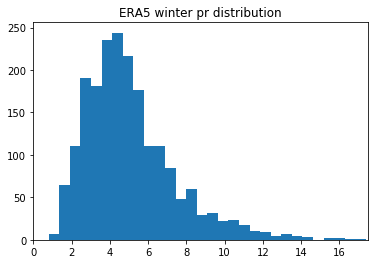

In [86]:
plt.hist(ERA5_tp_winter.values.flatten(),bins=30)
plt.xlim(0,17.5)
plt.title('ERA5 winter pr distribution')

Text(0.5, 1.0, 'gaussian ERA5 winter pr distribution')

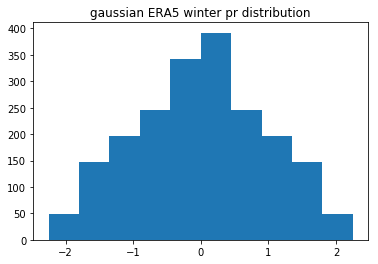

In [90]:
plt.hist(gaussian_winter_era5.flatten())#,bins=30)
plt.title('gaussian ERA5 winter pr distribution')

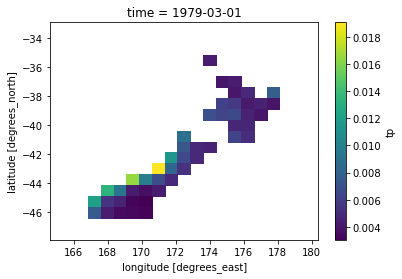

In [9]:
da.isel(time=0).plot()

In [33]:
ts

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan], dtype=float32)

In [11]:
def get_obs_data(season):
    
    ERA5_season = ERA5_tp.sel(time=ERA5_tp.time.dt.month.isin([season]))
    
    gaussian = q_map_to_gaussian(ERA5_season)
    
    print(gaussian.shape)
    
    return gaussian.flatten()

In [24]:
def get_mean_and_noise(season,scen):
    
    ens_mean = ens_means[scen].sel(time=ens_means[scen].time.dt.month.isin([season]))
    gaussian_ens_mean = q_map_to_gaussian(ens_mean)
    gaussian_ens_mean = gaussian_ens_mean.flatten()
        
    if scen == 'all':
        path = '../stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/pr/ens'
        file_name_setup = ['pr_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']
    if scen == 'nat':
        path = '../stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/Nat-Hist/obs-trend-1880s-est1/v1-0/mon/atmos/pr/ens'
        file_name_setup = ['pr_Amon_ECHAM5-4_Nat-Hist_obs-trend-1880s-est1_v1-0_ens','_197901-202006.nc']
    
    noise = []
    for ens_mem in range(1,51):
        
        #print(ens_mem)
        
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
        file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
        mem_ds = xr.open_dataset(file_path)
        
        mem_ds = mem_ds.sel(lon = slice(165,180),lat=slice(-33,-48))
        mem_ds = mem_ds.pr.where(ECHAM5_land_mask.sftlf > 0)
        mem_ds = mem_ds.resample(time='QS-DEC').mean()
        mem_ds = mem_ds.sel(time=slice('1978-12-01','2019-12-01'))
        mem_ds = mem_ds.sel(time=mem_ds.time.dt.month.isin([season]))
        
        gaussian_mem = q_map_to_gaussian(mem_ds)
        gaussian_mem = gaussian_mem.flatten()
        
        diff = gaussian_mem - gaussian_ens_mean
                
        noise.append(diff)

    return((gaussian_ens_mean, np.array(noise)))




In [33]:
path = '../stoneda/data/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/atmos/pr/ens'
file_name_setup = ['pr_Amon_ECHAM5-4_All-Hist_est1_v1-0_ens','_197901-202102.nc']

number = '02'
file_path = path + number + "/" + file_name_setup[0]+number+file_name_setup[1]
mem_ds = xr.open_dataset(file_path)

mem_ds = mem_ds.sel(lon = slice(165,180),lat=slice(-33,-48))
mem_ds = mem_ds.pr.where(ECHAM5_land_mask.sftlf > 0)
mem_ds = mem_ds.resample(time='QS-DEC').mean()
mem_ds = mem_ds.sel(time=slice('1978-12-01','2019-12-01'))
mem_ds = mem_ds.sel(time=mem_ds.time.dt.month.isin([6]))

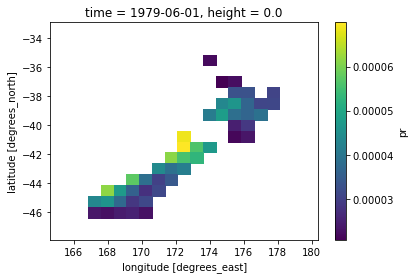

In [35]:
mem_ds.isel(time=0).plot()

(49, 41)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(2009,)
(49, 41)
(200

NameError: name 'seasons_a' is not defined

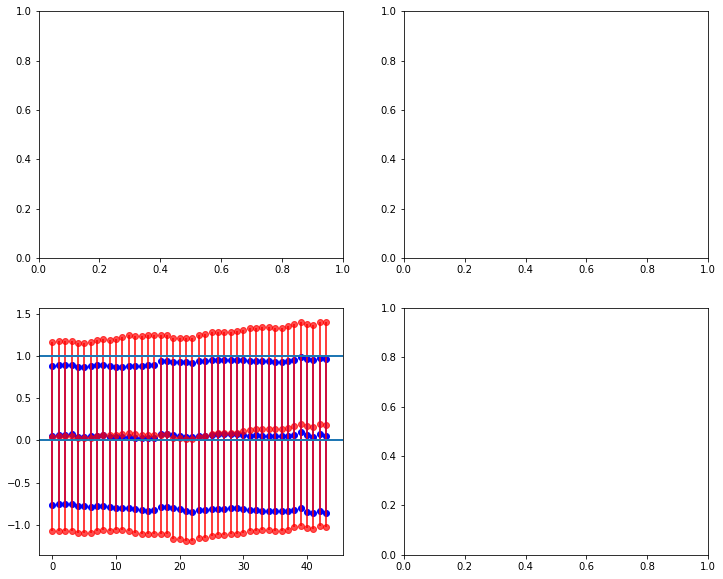

In [25]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)
axs = axs.flatten()

seasons = [12,3,6,9]
for i,s in enumerate(seasons):  
    if s != 6:
        continue

    IDL.retall
    
    all_ens_mean,noise_all = get_mean_and_noise(s,'all')
    nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat')
    
    data_obs = get_obs_data(s)
    
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
    data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
    
    trunc = np.array([i for i in range(3,48)])
    
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.scan_resid_sumsq = []
    IDL.p_resid = []
    IDL.resid_sumsq = []
    IDL.noise_singval = []
    IDL.z_best = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

    beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    scan_resid_sumsq = IDL.scan_resid_sumsq
    noise_singval = IDL.noise_singval
    z_best = IDL.z_best
        
    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        axs[i].scatter([j]*3,[low_1,best_1,up_1],c='blue',label='ant' if j == 0 else '')
        axs[i].scatter([j]*3,[low_2,best_2,up_2],c='red',alpha=0.7,label='nat' if j == 0 else '')

        axs[i].vlines(j,low_1,up_1,colors=['blue'])
        axs[i].vlines(j,low_2,up_2,colors=['red'])
        
        axs[i].axhline(0,-0.5,1.5)
        axs[i].axhline(1,-0.5,1.5)

    
    axs[i].set_title(seasons_a[s] + ', Trunc = ' + str(IDL.trunc))

    axs[i].legend()
    

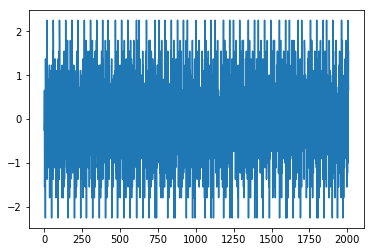

In [30]:
plt.plot(data_scen[1])

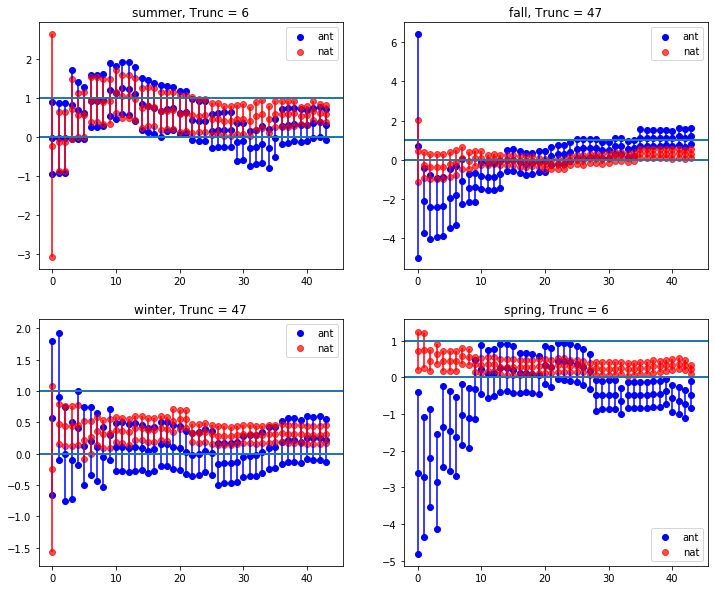

In [55]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)

season_residuals = []
season_est_obs = []
season_obs = []

seasons = ['summer','fall','winter','spring']
for i,ax in enumerate(axs.flatten()):
    
    season = seasons[i]
        
    season_n = {'fall':3,'winter':6,'spring':9,'summer':12}[season]
    IDL.retall
    
    data_obs = get_obs_data('obs',season)
    
    all_ens_mean,noise_all,all_ens = get_mean_and_noise(season_n,'all','annual')
    nat_ens_mean,noise_nat,nat_ens = get_mean_and_noise(season_n,'nat','annual')
    
    data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
    data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
    
    data_scen = np.array([all_ens_mean,nat_ens_mean])
    
    trunc = np.array([i for i in range(3,48)])
    #trunc = 25
    
    B = ax.boxplot(data_obs)
    
    #a = min(data_obs)
    #b = max(data_obs)
    
    a=B['whiskers'][0].get_ydata()[1]
    b=B['whiskers'][1].get_ydata()[1]
        
    ax.clear()
    
    def scale(ary):
        mn = min(ary.flatten())
        mx = max(ary.flatten())
        
        new_ary = np.zeros(ary.shape)
        for i in range(ary.shape[0]):
            for j in range(ary.shape[1]):
                val = ary[i][j]
                new_ary[i][j] = (((b-a)*(val-mn))/(mx-mn))+a
                    
        return new_ary
        
    new_noise_1 = scale(data_noise_1)
    new_noise_2 = scale(data_noise_2)    
    
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = new_noise_1
    IDL.data_noise_2 = new_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.scan_resid_sumsq = []
    IDL.p_resid = []
    IDL.resid_sumsq = []
    IDL.noise_singval = []
    IDL.z_best = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

    #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
    #        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc,\
    #        noise_singval=noise_singval,z_best=z_best")
    
    beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    scan_resid_sumsq = IDL.scan_resid_sumsq
    noise_singval = IDL.noise_singval
    z_best = IDL.z_best
    
    for i in range(len(scan_beta_est)):

        beta_est = scan_beta_est[i]
        
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        ax.scatter([i for j in range(3)],[low_1,best_1,up_1],c='blue',label='ant' if i == 0 else '')
        ax.scatter([i for j in range(3)],[low_2,best_2,up_2],c='red',alpha=0.7,label='nat' if i == 0 else '')
        #ax.text(0.4,0.9,'p_resid = ' + str(p_resid[i]),transform=ax.transAxes)
        ax.vlines(i,low_1,up_1,colors=['blue'])
        ax.vlines(i,low_2,up_2,colors=['red'])
        ax.axhline(0,-0.5,1.5)
        ax.axhline(1,-0.5,1.5)
    #ax.set_xlim(-0.5,1.5)
    #ax.set_ylim(-10,5)
    
    
    ax.set_title(season + ', Trunc = ' + str(IDL.trunc))
    #ax.set_ylim(-0.0001, 0.00027)
    #if season != 'summer':
    #    ax.set_ylim(0,0.4)
    ax.legend()
    
    
    

In [ ]:
'''
MAIN PROGRAM

Create a seasonal plot of the regression coefficients using an array of trunctions.
The plots are saved in ~/figures/fingerprinting/scan_beta_est.
'''

fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)

season_residuals = []
season_est_obs = []
season_obs = []

seasons = ['summer','fall','winter','spring']
for i,ax in enumerate(axs.flatten()):
    
    season = seasons[i]
        
    season_n = {'fall':3,'winter':6,'spring':9,'summer':12}[season]
    IDL.retall
    
    data_obs = get_obs_data('obs',season)
    
    all_ens_mean,noise_all,all_ens = get_mean_and_noise(season_n,'all','annual')
    nat_ens_mean,noise_nat,nat_ens = get_mean_and_noise(season_n,'nat','annual')
    
    data_noise_1 = np.concatenate((noise_all[:25],noise_nat[:25]))
    data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
    
    data_scen = np.array([all_ens_mean,nat_ens_mean])
    
    trunc = np.array([i for i in range(3,48)])
    #trunc = 25
    
    B = ax.boxplot(data_obs)
    
    #a = min(data_obs)
    #b = max(data_obs)
    
    a=B['whiskers'][0].get_ydata()[1]
    b=B['whiskers'][1].get_ydata()[1]
        
    ax.clear()
    
    def scale(ary):
        mn = min(ary.flatten())
        mx = max(ary.flatten())
        
        new_ary = np.zeros(ary.shape)
        for i in range(ary.shape[0]):
            for j in range(ary.shape[1]):
                val = ary[i][j]
                new_ary[i][j] = (((b-a)*(val-mn))/(mx-mn))+a
                    
        return new_ary
        
    new_noise_1 = scale(data_noise_1)
    new_noise_2 = scale(data_noise_2)    
    
    data_noise_1 = new_noise_1
    data_noise_2 = new_noise_2
    
    
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.scan_resid_sumsq = []
    IDL.p_resid = []
    IDL.resid_sumsq = []
    IDL.noise_singval = []
    IDL.z_best = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

    #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
    #        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc,\
    #        noise_singval=noise_singval,z_best=z_best")
    
    beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    scan_resid_sumsq = IDL.scan_resid_sumsq
    noise_singval = IDL.noise_singval
    z_best = IDL.z_best
    
    for i in range(len(scan_beta_est)):

        beta_est = scan_beta_est[i]
        
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        ax.scatter([i for j in range(3)],[low_1,best_1,up_1],c='blue',label='ant' if i == 0 else '')
        ax.scatter([i for j in range(3)],[low_2,best_2,up_2],c='red',alpha=0.7,label='nat' if i == 0 else '')
        #ax.text(0.4,0.9,'p_resid = ' + str(p_resid[i]),transform=ax.transAxes)
        ax.vlines(i,low_1,up_1,colors=['blue'])
        ax.vlines(i,low_2,up_2,colors=['red'])
        ax.axhline(0,-0.5,1.5)
        ax.axhline(1,-0.5,1.5)
    #ax.set_xlim(-0.5,1.5)
    #ax.set_ylim(-10,5)
    
    
    ax.set_title(season + ', Trunc = ' + str(IDL.trunc))
    #ax.set_ylim(-0.0001, 0.00027)
    #if season != 'summer':
    #    ax.set_ylim(0,0.4)
    ax.legend()
    
    
    

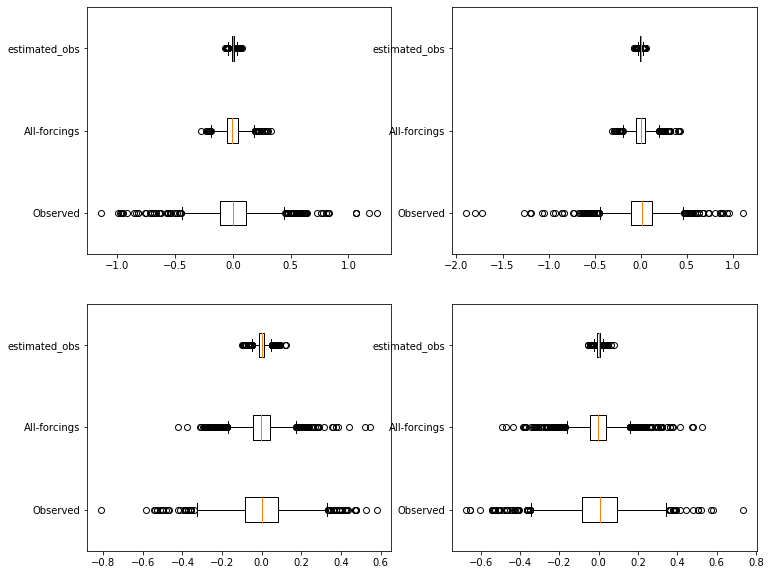

In [18]:
fig,axs = plt.subplots(2,2, figsize=(12,10))#, sharex=True,sharey=True)

seasons = ['summer','fall','winter','spring']
for i,ax in enumerate(axs.flatten()):
    
    season = seasons[i]
    season_n = {'fall':3,'winter':6,'spring':9,'summer':12}[season]
    
    data_obs = season_obs[i]
    data_est_obs = season_est_obs[i]
    data_all,noise_all = get_mean_and_noise(season_n,'all','annual')
    
    ax.boxplot([data_obs,data_all,data_est_obs],vert=False,labels=['Observed','All-forcings','estimated_obs'])
    #ax.hist(data_obs,bins,alpha=0.8,label='observed flow')
    #ax.hist(data_scen[0],bins,alpha=0.7,label='All-forcings runoff')
    
    #ax.set_xticks([0.0001*i for i in range(5)])
    #ax.text(0.0002,1.5,'difference of means:\n' + str(np.mean(data_obs) - np.mean(data_scen[0])))

    #ax.set_xlim(-0.0003,0.0003)
    #ax.text(0.00015,600,'difference of means:\n' + str(np.mean(data_obs) - np.mean(data_scen[0])))

    
    #if i == 0:
    #    ax.legend()
    


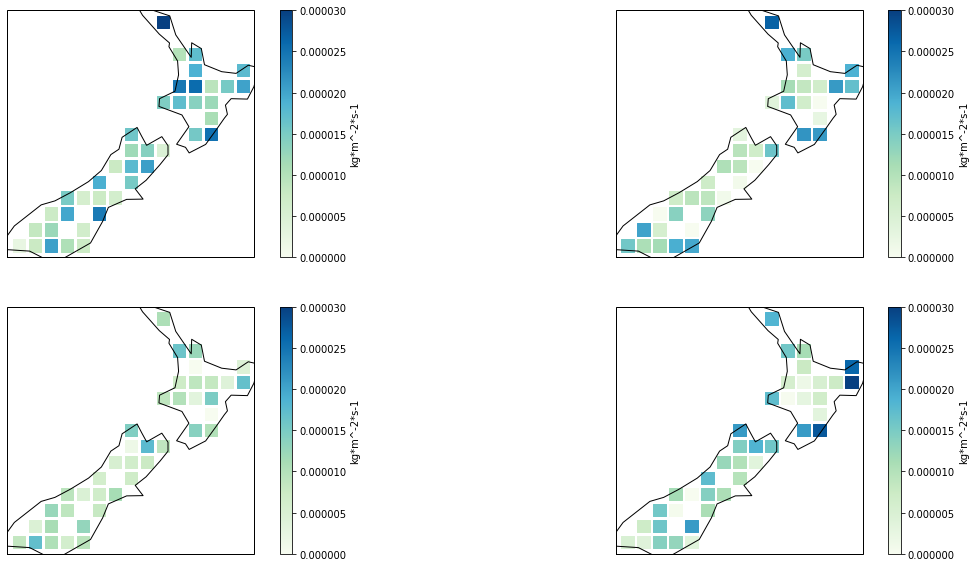

In [15]:
seasons = ['winter']#,'spring','summer''fall',]
scen = ['obs','nat','anth']
fig,axs = plt.subplots(2,2,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(20,10))

obs_df = pd.read_csv('data/runoff/' + season + '_obs.csv')
obs_df = obs_df.set_index('date')


for s,ax in enumerate(axs.flatten()):
    
    residual = season_residuals[s].reshape(41,40)
    
    lons = [float(c.split(' ')[1]) for c in obs_df.columns]
    lats = [float(c.split(' ')[0]) for c in obs_df.columns]

    vals = []
    for cell in range(41):
        vals.append(np.mean(residual[cell]))

    im = ax.scatter(lons,lats,c=vals,cmap='GnBu',marker='s',s=150,vmin=0,vmax=0.00003) 
    fig.colorbar(im,ax=ax,label='kg*m^-2*s-1')
    ax.coastlines()
        
        